# Limpieza de Datos - Pregunta 1
**Pregunta de negocio:** ¿Cuál será el nivel de desempeño en matemáticas de un estudiante de Cundinamarca según su tipo de colegio?


In [22]:
#libreriass
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

#cargar datos y descomprimirlos porque estan en un .zip en el git
df = pd.read_csv('df_filtrado.csv.zip', compression= "zip")
df.columns

Index(['PERIODO', 'COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_GENERO',
       'COLE_JORNADA', 'COLE_MCPIO_UBICACION', 'ESTU_FECHANACIMIENTO',
       'ESTU_GENERO', 'ESTU_PAIS_RESIDE', 'FAMI_CUARTOSHOGAR',
       'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA',
       'FAMI_PERSONASHOGAR', 'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR',
       'FAMI_TIENEINTERNET', 'FAMI_TIENELAVADORA', 'PUNT_GLOBAL',
       'PUNT_MATEMATICAS'],
      dtype='object')

## 1. Columnas relevantes

In [23]:

#columnas base
columnas = [
    'COLE_AREA_UBICACION',
    'COLE_BILINGUE',
    'COLE_GENERO',
    'COLE_JORNADA',
    'PUNT_MATEMATICAS'
]

df = df[columnas].copy()

#texto a numeros
df['COLE_BILINGUE_NUM']       = df['COLE_BILINGUE'].map({'S': 1, 'N': 0})
df['COLE_AREA_UBICACION_NUM'] = df['COLE_AREA_UBICACION'].map({'URBANO': 0, 'RURAL': 1})

#dummies y one hot
df = pd.get_dummies(df, columns=['COLE_GENERO', 'COLE_JORNADA'])

#alto vs no alto 
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)
df['NIVEL_MATEMATICAS'] = (df['PUNT_MATEMATICAS'] >= p66).astype(int)
#1 = Alto, 0 = No-Alto

#df limpio
df_limpio = df[[
    'COLE_AREA_UBICACION_NUM',
    'COLE_BILINGUE_NUM',
    *[c for c in df.columns if 'COLE_GENERO_' in c],
    *[c for c in df.columns if 'COLE_JORNADA_' in c],
    'PUNT_MATEMATICAS',
    'NIVEL_MATEMATICAS',
]].copy()

#limpieza final sin nan
df_limpio = df_limpio.apply(pd.to_numeric, errors='coerce')
df_limpio = df_limpio.dropna().reset_index(drop=True)

print(f'Umbral Alto: >= {p66:.1f}')
print(f'Shape: {df_limpio.shape}')
print(f'\nDistribución:')
print(df_limpio['NIVEL_MATEMATICAS'].value_counts().rename({0: 'No-Alto', 1: 'Alto'}))
df_limpio.head()

Umbral Alto: >= 55.0
Shape: (393265, 13)

Distribución:
NIVEL_MATEMATICAS
No-Alto    252664
Alto       140601
Name: count, dtype: int64


,COLE_AREA_UBICACION_NUM,COLE_BILINGUE_NUM,COLE_GENERO_FEMENINO,COLE_GENERO_MASCULINO,COLE_GENERO_MIXTO,COLE_JORNADA_COMPLETA,COLE_JORNADA_MAÑANA,COLE_JORNADA_NOCHE,COLE_JORNADA_SABATINA,COLE_JORNADA_TARDE,COLE_JORNADA_UNICA,PUNT_MATEMATICAS,NIVEL_MATEMATICAS
0,0.0,0.0,False,False,True,False,False,False,False,False,True,26.0,0
1,0.0,0.0,False,False,True,False,False,False,True,False,False,60.0,1
2,0.0,0.0,False,False,True,True,False,False,False,False,False,54.0,0
3,1.0,0.0,False,False,True,False,False,False,True,False,False,45.0,0
4,0.0,0.0,False,False,True,False,False,False,False,False,True,64.0,1


## 2. Calidad de datos por columna

In [24]:

#nivel bajo o alto
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)
df['NIVEL_MATEMATICAS'] = (df['PUNT_MATEMATICAS'] >= p66).astype(int)

#df limpio con todo
df_limpio = df[[
    'COLE_AREA_UBICACION_NUM',
    'COLE_BILINGUE_NUM',
    *[c for c in df.columns if 'COLE_GENERO_' in c],
    *[c for c in df.columns if 'COLE_JORNADA_' in c],
    'PUNT_MATEMATICAS',
    'NIVEL_MATEMATICAS',
]].copy()

df_limpio = df_limpio.apply(pd.to_numeric, errors='coerce')
df_limpio = df_limpio.dropna().reset_index(drop=True)

print(df_limpio.head())

   COLE_AREA_UBICACION_NUM  COLE_BILINGUE_NUM  COLE_GENERO_FEMENINO  \
0                      0.0                0.0                 False   
1                      0.0                0.0                 False   
2                      0.0                0.0                 False   
3                      1.0                0.0                 False   
4                      0.0                0.0                 False   

   COLE_GENERO_MASCULINO  COLE_GENERO_MIXTO  COLE_JORNADA_COMPLETA  \
0                  False               True                  False   
1                  False               True                  False   
2                  False               True                   True   
3                  False               True                  False   
4                  False               True                  False   

   COLE_JORNADA_MAÑANA  COLE_JORNADA_NOCHE  COLE_JORNADA_SABATINA  \
0                False               False                  False   
1             

In [25]:
print('Valores únicos por columna\n')

columnas = df_limpio.columns   #las que se crearon antes con todas

for col in columnas:
    print(f'--- {col} ---')
    print(df_limpio[col].value_counts(dropna=False))
    print()

Valores únicos por columna

--- COLE_AREA_UBICACION_NUM ---
COLE_AREA_UBICACION_NUM
0.0    320952
1.0     72313
Name: count, dtype: int64

--- COLE_BILINGUE_NUM ---
COLE_BILINGUE_NUM
0.0    387178
1.0      6087
Name: count, dtype: int64

--- COLE_GENERO_FEMENINO ---
COLE_GENERO_FEMENINO
False    388968
True       4297
Name: count, dtype: int64

--- COLE_GENERO_MASCULINO ---
COLE_GENERO_MASCULINO
False    391675
True       1590
Name: count, dtype: int64

--- COLE_GENERO_MIXTO ---
COLE_GENERO_MIXTO
True     387378
False      5887
Name: count, dtype: int64

--- COLE_JORNADA_COMPLETA ---
COLE_JORNADA_COMPLETA
False    293759
True      99506
Name: count, dtype: int64

--- COLE_JORNADA_MAÑANA ---
COLE_JORNADA_MAÑANA
False    215484
True     177781
Name: count, dtype: int64

--- COLE_JORNADA_NOCHE ---
COLE_JORNADA_NOCHE
False    367696
True      25569
Name: count, dtype: int64

--- COLE_JORNADA_SABATINA ---
COLE_JORNADA_SABATINA
False    368983
True      24282
Name: count, dtype: int64

--- C

## 3. Letras a numeros (df_modelo)

In [26]:
#df limpio y finalmente df modelo
df_modelo = df_limpio.copy()

#esto era antes
if 'NIVEL_MATEMATICAS' in df_modelo.columns:
    df_modelo = df_modelo.drop(columns=['NIVEL_MATEMATICAS'])

#objetivo: binario alto o no alto
p66 = df_modelo['PUNT_MATEMATICAS'].quantile(0.66)

df_modelo['ALTO_RENDIMIENTO'] = (
    df_modelo['PUNT_MATEMATICAS'] >= p66
).astype(int)

#columnas finales
CARACTERISTICAS = [
    col for col in df_modelo.columns
    if col not in ['PUNT_MATEMATICAS', 'ALTO_RENDIMIENTO']
]

TARGET = 'ALTO_RENDIMIENTO'

#limpieza final
df_modelo = df_modelo.apply(pd.to_numeric, errors='coerce')
df_modelo = df_modelo.dropna().reset_index(drop=True)

df_modelo[CARACTERISTICAS] = df_modelo[CARACTERISTICAS].astype(int)

#verificar
print("Distribución:")
print(df_modelo[TARGET].value_counts().rename({0: 'No-Alto', 1: 'Alto'}))

df_modelo.head()


Distribución:
ALTO_RENDIMIENTO
No-Alto    252664
Alto       140601
Name: count, dtype: int64


,COLE_AREA_UBICACION_NUM,COLE_BILINGUE_NUM,COLE_GENERO_FEMENINO,COLE_GENERO_MASCULINO,COLE_GENERO_MIXTO,COLE_JORNADA_COMPLETA,COLE_JORNADA_MAÑANA,COLE_JORNADA_NOCHE,COLE_JORNADA_SABATINA,COLE_JORNADA_TARDE,COLE_JORNADA_UNICA,PUNT_MATEMATICAS,ALTO_RENDIMIENTO
0,0,0,0,0,1,0,0,0,0,0,1,26.0,0
1,0,0,0,0,1,0,0,0,1,0,0,60.0,1
2,0,0,0,0,1,1,0,0,0,0,0,54.0,0
3,1,0,0,0,1,0,0,0,1,0,0,45.0,0
4,0,0,0,0,1,0,0,0,0,0,1,64.0,1


# Exploración de Datos - Pregunta 1
**Pregunta de negocio:** ¿Cuál será el nivel de desempeño en matemáticas de un estudiante de Cundinamarca según su tipo de colegio?


## 3. Distribución de PUNT_MATEMATICAS y definición de categorías

In [27]:
print('Estadísticas de PUNT_MATEMATICAS')
print(df['PUNT_MATEMATICAS'].describe()) #estadisticas clave

#binaria
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)

print(f'\nUmbral de alto rendimiento (P66): {p66:.1f}')

#binaria
df['ALTO_RENDIMIENTO'] = (df['PUNT_MATEMATICAS'] >= p66).astype(int)

print('\nDistribución:')
print(df['ALTO_RENDIMIENTO'].value_counts().rename({0: 'No-Alto', 1: 'Alto'}))

print('\nProporciones:')
print(df['ALTO_RENDIMIENTO'].value_counts(normalize=True))

Estadísticas de PUNT_MATEMATICAS
count    470818.000000
mean         50.777481
std          11.344459
min           0.000000
25%          43.000000
50%          50.670000
75%          58.000000
max         127.000000
Name: PUNT_MATEMATICAS, dtype: float64

Umbral de alto rendimiento (P66): 55.0

Distribución:
ALTO_RENDIMIENTO
No-Alto    298413
Alto       172405
Name: count, dtype: int64

Proporciones:
ALTO_RENDIMIENTO
0    0.633818
1    0.366182
Name: proportion, dtype: float64


In [28]:
#umbral
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)

print(f'Umbral de alto rendimiento:')
print(f'  Alto     : PUNT_MATEMATICAS >= {p66:.1f}')
print(f'  No-Alto  : PUNT_MATEMATICAS < {p66:.1f}')

# binario
def categorizar_binario(puntaje):
    if pd.isna(puntaje):
        return np.nan
    elif puntaje >= p66:
        return 'Alto'
    else:
        return 'No-Alto'

#categorizar
df['NIVEL_MATEMATICAS'] = df['PUNT_MATEMATICAS'].apply(categorizar_binario)

#resultados
print('\n=== Distribución de categorías ===')
print(df['NIVEL_MATEMATICAS'].value_counts())

print('\n=== Proporciones ===')
print(df['NIVEL_MATEMATICAS'].value_counts(normalize=True))

Umbral de alto rendimiento:
  Alto     : PUNT_MATEMATICAS >= 55.0
  No-Alto  : PUNT_MATEMATICAS < 55.0

=== Distribución de categorías ===
NIVEL_MATEMATICAS
No-Alto    298413
Alto       172405
Name: count, dtype: int64

=== Proporciones ===
NIVEL_MATEMATICAS
No-Alto    0.633818
Alto       0.366182
Name: proportion, dtype: float64


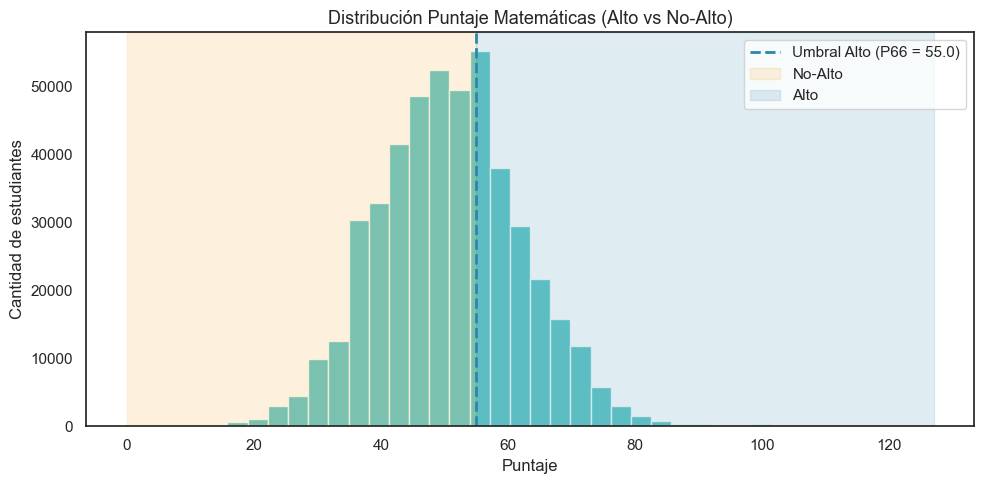

In [29]:
plt.figure(figsize=(10, 5), facecolor='white')
plt.grid(False)

#histograma con los datos 
plt.hist(
    df['PUNT_MATEMATICAS'].dropna(),
    bins=40,
    color='#4ABFBF',
    edgecolor='white',
    alpha=0.85
)

#marcar umbral
plt.axvline(
    p66,
    color='#2E86AB',
    linestyle='--',
    linewidth=2,
    label=f'Umbral Alto (P66 = {p66:.1f})'
)

#binario
plt.axvspan(
    df['PUNT_MATEMATICAS'].min(),
    p66,
    alpha=0.15,
    color='#F5A623',
    label='No-Alto'
)

plt.axvspan(
    p66,
    df['PUNT_MATEMATICAS'].max(),
    alpha=0.15,
    color='#2E86AB',
    label='Alto'
)

#etiquetas
plt.title('Distribución Puntaje Matemáticas (Alto vs No-Alto)', fontsize=13)
plt.xlabel('Puntaje')
plt.ylabel('Cantidad de estudiantes')

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
#colores de la pp
C = {'No-Alto': '#F5A623', 'Alto': '#2E86AB'}
ORDEN = ['No-Alto', 'Alto']

sns.set_theme(style='whitegrid', font_scale=1.05)

#umbral
p66 = df['PUNT_MATEMATICAS'].quantile(0.66)

#variable binaria
df['NIVEL_MATEMATICAS'] = (
    df['PUNT_MATEMATICAS'] >= p66
).map({True: 'Alto', False: 'No-Alto'})

#imprimir bonito
print(f'Registros: {len(df_limpio):,}   |  Umbral P66 = {p66:.1f}')

print('\nDistribución:')
print(
    df['NIVEL_MATEMATICAS']
    .value_counts()
    .reindex(ORDEN)
)

print('\nProporciones:')
print(
    df['NIVEL_MATEMATICAS']
    .value_counts(normalize=True)
    .reindex(ORDEN)
)

Registros: 393,265   |  Umbral P66 = 55.0

Distribución:
NIVEL_MATEMATICAS
No-Alto    298413
Alto       172405
Name: count, dtype: int64

Proporciones:
NIVEL_MATEMATICAS
No-Alto    0.633818
Alto       0.366182
Name: proportion, dtype: float64


## Histogramas

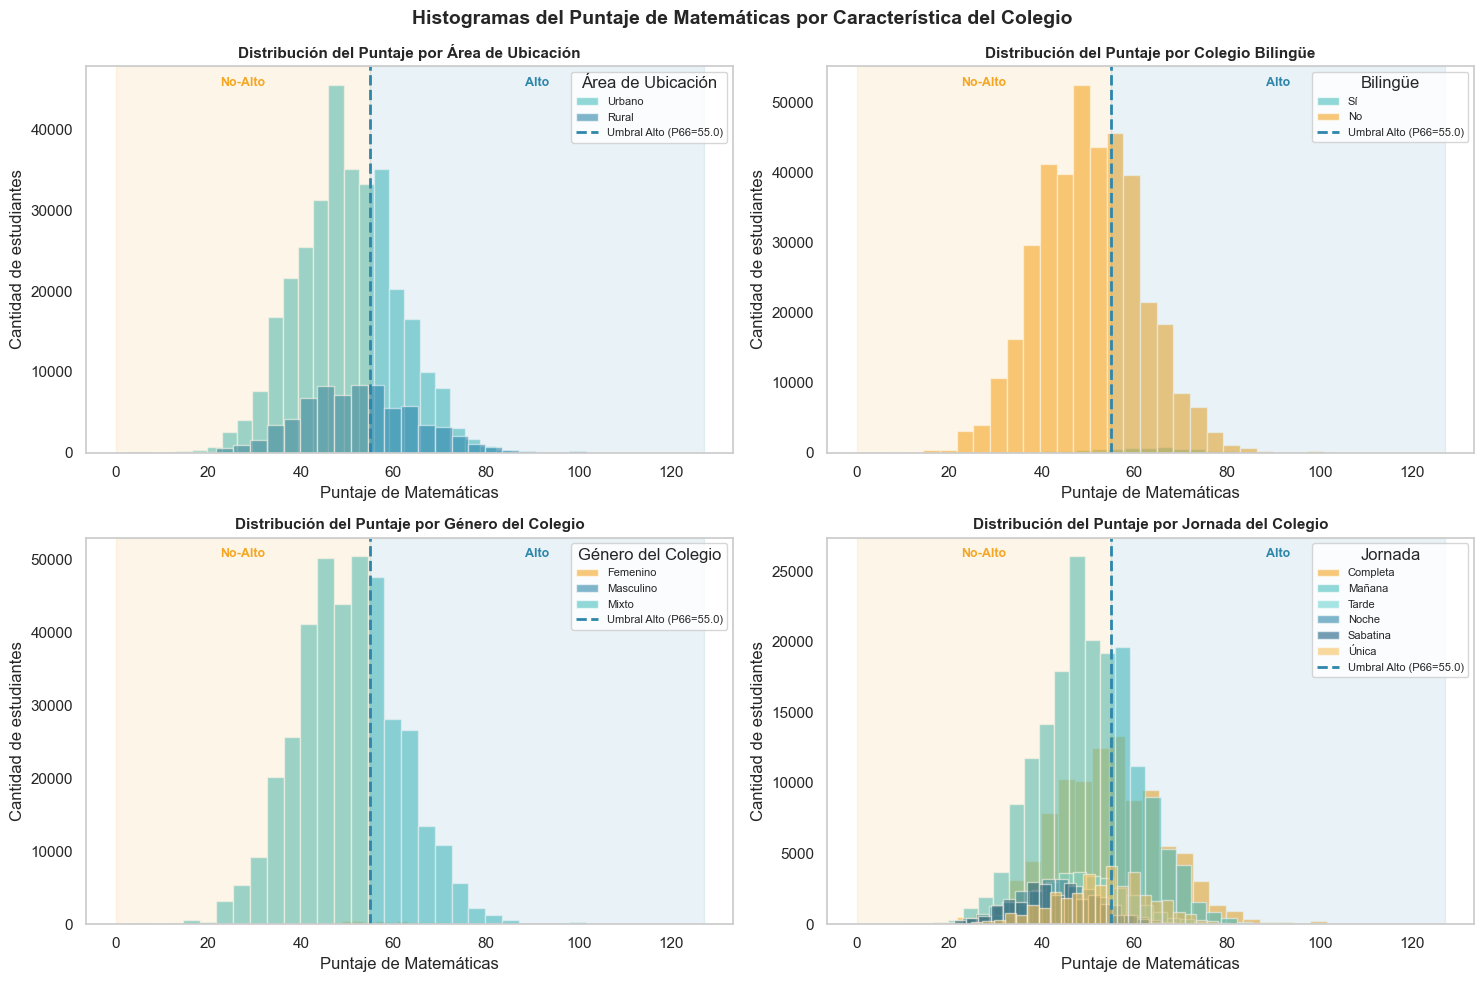

In [31]:
#nombres 
df_plot = df_limpio.copy()

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')

#umbral binario
p66 = df_plot['PUNT_MATEMATICAS'].quantile(0.66)
ymin = df_plot['PUNT_MATEMATICAS'].min()
ymax = df_plot['PUNT_MATEMATICAS'].max()

#colores de la pp
C_BAJO = '#F5A623'
C_ALTO = '#2E86AB'

#histograma
def plot_hist(ax, datos_dict, titulo, label_legend):

    for nombre, (datos, color) in datos_dict.items():
        ax.hist(
            datos,
            bins=35,
            alpha=0.6,
            label=nombre,
            color=color,
            edgecolor='white'
        )

    # sombreado
    ax.axvspan(ymin, p66, alpha=0.10, color=C_BAJO)
    ax.axvspan(p66, ymax, alpha=0.10, color=C_ALTO)

    # línea
    ax.axvline(p66, color=C_ALTO, linestyle='--', linewidth=2,
               label=f'Umbral Alto (P66={p66:.1f})')

    # etiquetas de zonas
    ax.text((ymin+p66)/2, ax.get_ylim()[1]*0.95, 'No-Alto',
            color=C_BAJO, ha='center', fontsize=9, fontweight='bold')

    ax.text((p66+ymax)/2, ax.get_ylim()[1]*0.95, 'Alto',
            color=C_ALTO, ha='center', fontsize=9, fontweight='bold')

    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Puntaje de Matemáticas')
    ax.set_ylabel('Cantidad de estudiantes')
    ax.legend(title=label_legend, fontsize=8)
    ax.grid(False)


#subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10), facecolor='white')
axes = axes.flatten()

#area
plot_hist(
    axes[0],
    {
        'Urbano': (df_plot[df_plot['COLE_AREA_UBICACION_NUM'] == 0]['PUNT_MATEMATICAS'], '#4ABFBF'),
        'Rural':  (df_plot[df_plot['COLE_AREA_UBICACION_NUM'] == 1]['PUNT_MATEMATICAS'], '#2E86AB'),
    },
    'Distribución del Puntaje por Área de Ubicación',
    'Área de Ubicación'
)

#bilingue o no 
plot_hist(
    axes[1],
    {
        'Sí': (df_plot[df_plot['COLE_BILINGUE_NUM'] == 1]['PUNT_MATEMATICAS'], '#4ABFBF'),
        'No': (df_plot[df_plot['COLE_BILINGUE_NUM'] == 0]['PUNT_MATEMATICAS'], '#F5A623'),
    },
    'Distribución del Puntaje por Colegio Bilingüe',
    'Bilingüe'
)

#nombres bonitos del genero
plot_hist(
    axes[2],
    {
        'Femenino':  (df_plot[df_plot.get('COLE_GENERO_FEMENINO',0)==1]['PUNT_MATEMATICAS'], '#F5A623'),
        'Masculino': (df_plot[df_plot.get('COLE_GENERO_MASCULINO',0)==1]['PUNT_MATEMATICAS'], '#2E86AB'),
        'Mixto':     (df_plot[df_plot.get('COLE_GENERO_MIXTO',0)==1]['PUNT_MATEMATICAS'], '#4ABFBF'),
    },
    'Distribución del Puntaje por Género del Colegio',
    'Género del Colegio'
)

#nombres bonitos para la jornada
# ── 4. jornada ─────────────────────────
plot_hist(
    axes[3],
    {
        'Completa': (df_plot[df_plot.get('COLE_JORNADA_COMPLETA',0)==1]['PUNT_MATEMATICAS'], '#F5A623'),
        'Mañana':   (df_plot[df_plot.get('COLE_JORNADA_MAÑANA',0)==1]['PUNT_MATEMATICAS'], '#4ABFBF'),
        'Tarde':    (df_plot[df_plot.get('COLE_JORNADA_TARDE',0)==1]['PUNT_MATEMATICAS'], '#6FD4D4'),
        'Noche':    (df_plot[df_plot.get('COLE_JORNADA_NOCHE',0)==1]['PUNT_MATEMATICAS'], '#2E86AB'),
        'Sabatina': (df_plot[df_plot.get('COLE_JORNADA_SABATINA',0)==1]['PUNT_MATEMATICAS'], '#1B5E84'),
        'Única':    (df_plot[df_plot.get('COLE_JORNADA_UNICA',0)==1]['PUNT_MATEMATICAS'], '#F8C15C'),
    },
    'Distribución del Puntaje por Jornada del Colegio',
    'Jornada'
)

plt.suptitle('Histogramas del Puntaje de Matemáticas por Característica del Colegio',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Diagrama de caja y bigotes

C:\Users\danis\AppData\Local\Temp\ipykernel_24700\1587413961.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


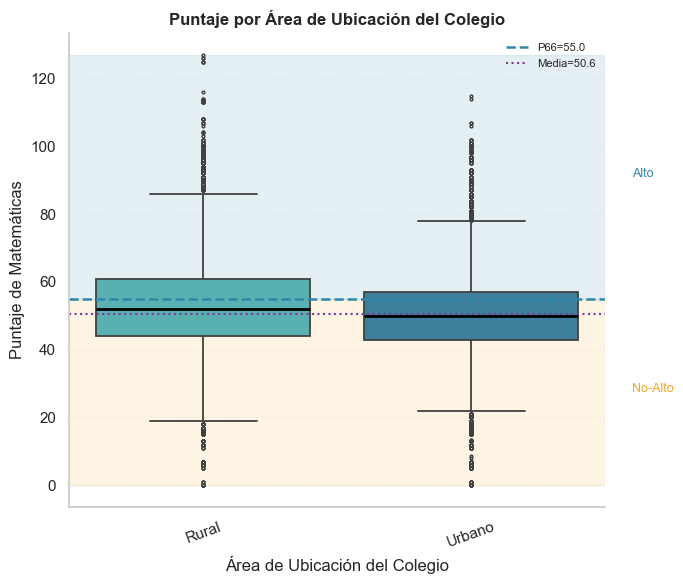

C:\Users\danis\AppData\Local\Temp\ipykernel_24700\1587413961.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


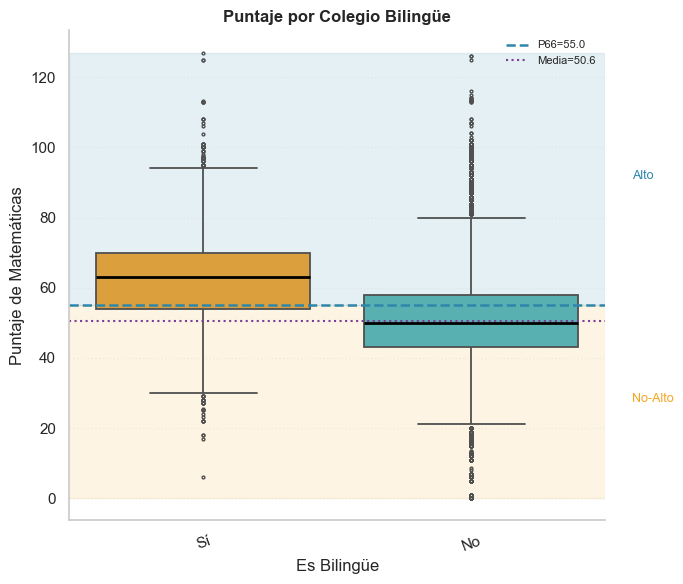

C:\Users\danis\AppData\Local\Temp\ipykernel_24700\1587413961.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


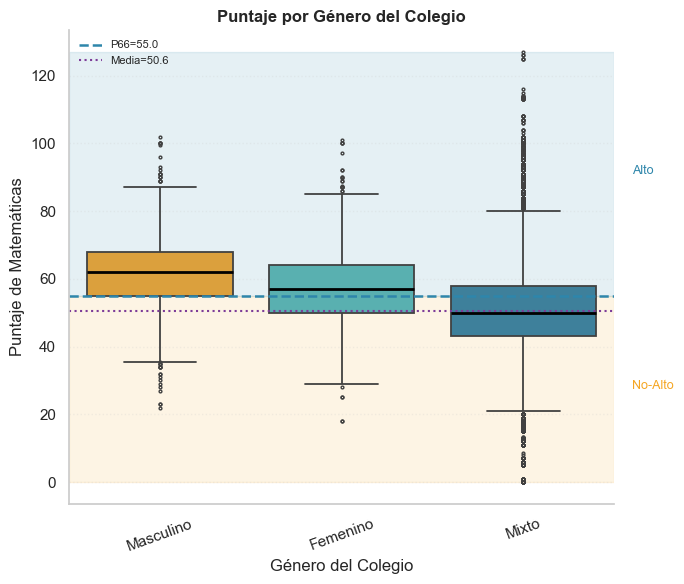

C:\Users\danis\AppData\Local\Temp\ipykernel_24700\1587413961.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


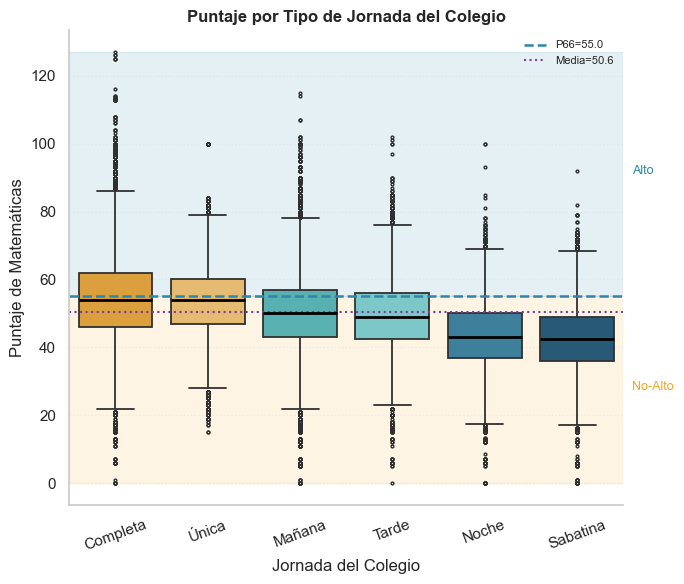

In [32]:
#colores de la pp
C = {
    'No-Alto': '#F5A623',
    'Alto': '#2E86AB'
}

PALETAS = {
    'AREA': ['#4ABFBF', '#2E86AB'],
    'BILINGUE': ['#F5A623', '#4ABFBF'],
    'GENERO': ['#F5A623', '#4ABFBF', '#2E86AB'],
    'JORNADA': ['#F5A623', '#F8C15C', '#4ABFBF',
                '#6FD4D4', '#2E86AB', '#1B5E84'],
}

#titulos
TITULOS_SUBPLOTS = {
    'AREA': "Puntaje por Área de Ubicación del Colegio",
    'BILINGUE': "Puntaje por Colegio Bilingüe",
    'GENERO': "Puntaje por Género del Colegio",
    'JORNADA': "Puntaje por Tipo de Jornada del Colegio"
}

XLABELS = {
    'AREA': "Área de Ubicación del Colegio",
    'BILINGUE': "Es Bilingüe",
    'GENERO': "Género del Colegio",
    'JORNADA': "Jornada del Colegio"
}

YLABEL = "Puntaje de Matemáticas"

#df limpio
df_plot = df_limpio.copy()

#umbral
p66   = df_plot['PUNT_MATEMATICAS'].quantile(0.66)
media = df_plot['PUNT_MATEMATICAS'].mean()
ymin  = df_plot['PUNT_MATEMATICAS'].min()
ymax  = df_plot['PUNT_MATEMATICAS'].max()

#variables
cats = [
    ('AREA', 'Área de Ubicación'),
    ('BILINGUE', 'Bilingüe'),
    ('GENERO', 'Género del Colegio'),
    ('JORNADA', 'Jornada'),
]

for var, label in cats:

    #NUEVA FIGURA PARA CADA CARACT
    fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')
    ax.set_facecolor('white')

    #categorias

    if var == 'AREA':
        df_plot['CAT'] = np.where(
            df_plot['COLE_AREA_UBICACION_NUM'] == 0, 'Urbano', 'Rural'
        )

    elif var == 'BILINGUE':
        df_plot['CAT'] = np.where(
            df_plot['COLE_BILINGUE_NUM'] == 1, 'Sí', 'No'
        )

    elif var == 'GENERO':
        df_plot['CAT'] = np.select(
            [
                df_plot.get('COLE_GENERO_FEMENINO',0)==1,
                df_plot.get('COLE_GENERO_MASCULINO',0)==1,
                df_plot.get('COLE_GENERO_MIXTO',0)==1
            ],
            ['Femenino', 'Masculino', 'Mixto'],
            default='Otro'
        )

    elif var == 'JORNADA':
        df_plot['CAT'] = np.select(
            [
                df_plot.get('COLE_JORNADA_COMPLETA',0)==1,
                df_plot.get('COLE_JORNADA_MAÑANA',0)==1,
                df_plot.get('COLE_JORNADA_TARDE',0)==1,
                df_plot.get('COLE_JORNADA_NOCHE',0)==1,
                df_plot.get('COLE_JORNADA_SABATINA',0)==1,
                df_plot.get('COLE_JORNADA_UNICA',0)==1
            ],
            ['Completa', 'Mañana', 'Tarde', 'Noche', 'Sabatina', 'Única'],
            default='Otro'
        )

    #ordenar por mediana
    orden_cat = (
        df_plot.groupby('CAT')['PUNT_MATEMATICAS']
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    palette = PALETAS[var]

    #caja
    sns.boxplot(
        data=df_plot,
        x='CAT',
        y='PUNT_MATEMATICAS',
        order=orden_cat,
        palette=palette,
        fliersize=2,
        linewidth=1.3,
        medianprops={'color': '#000000', 'linewidth': 2},
        ax=ax
    )

    #sombra de atras
    ax.axhspan(ymin, p66, alpha=0.12, color=C['No-Alto'], zorder=0)
    ax.axhspan(p66, ymax, alpha=0.12, color=C['Alto'], zorder=0)

    #lineas para separar
    ax.axhline(p66,   color=C['Alto'], ls='--', lw=1.8, label=f'P66={p66:.1f}')
    ax.axhline(media, color='#7D3C98', ls=':',  lw=1.5, label=f'Media={media:.1f}')

    #zonas binarias
    n_cats = len(orden_cat)
    ax.text(n_cats - 0.4, (ymin + p66)/2, 'No-Alto', color=C['No-Alto'], fontsize=9)
    ax.text(n_cats - 0.4, (p66 + ymax)/2, 'Alto', color=C['Alto'], fontsize=9)

    #bonito
    ax.set_title(TITULOS_SUBPLOTS[var], fontweight='bold', fontsize=12)
    ax.set_xlabel(XLABELS[var])
    ax.set_ylabel(YLABEL)

    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.25)

    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    plt.show()

## Diagramas de violín

C:\Users\danis\AppData\Local\Temp\ipykernel_24700\804105823.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


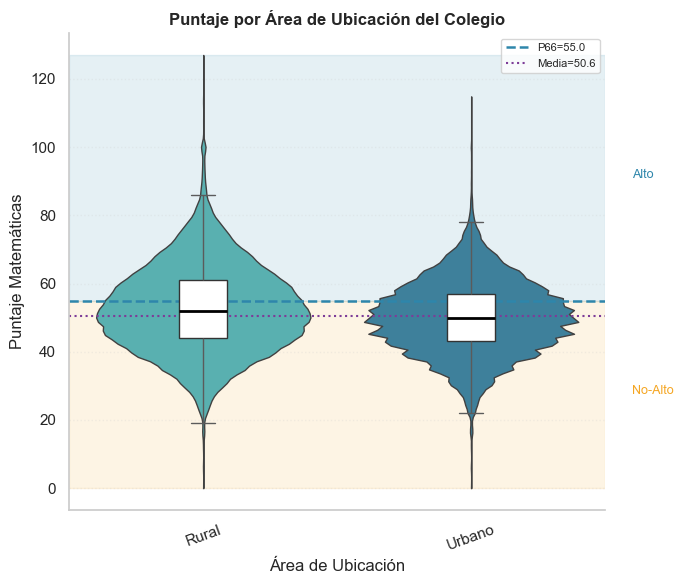

C:\Users\danis\AppData\Local\Temp\ipykernel_24700\804105823.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


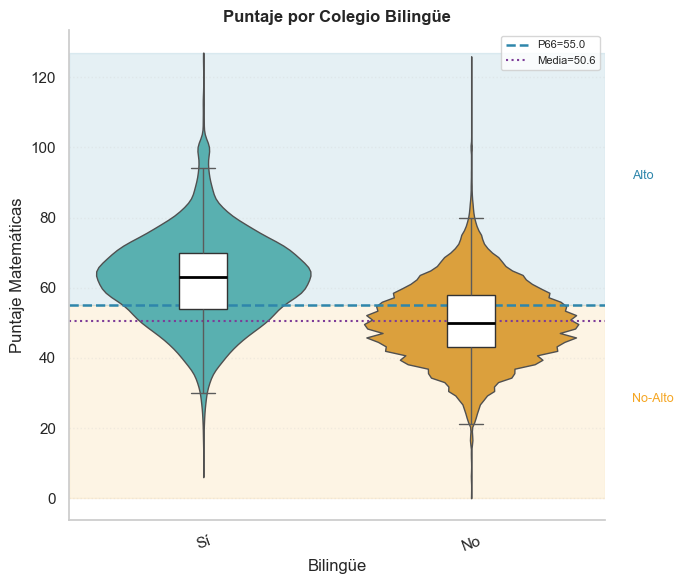

C:\Users\danis\AppData\Local\Temp\ipykernel_24700\804105823.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


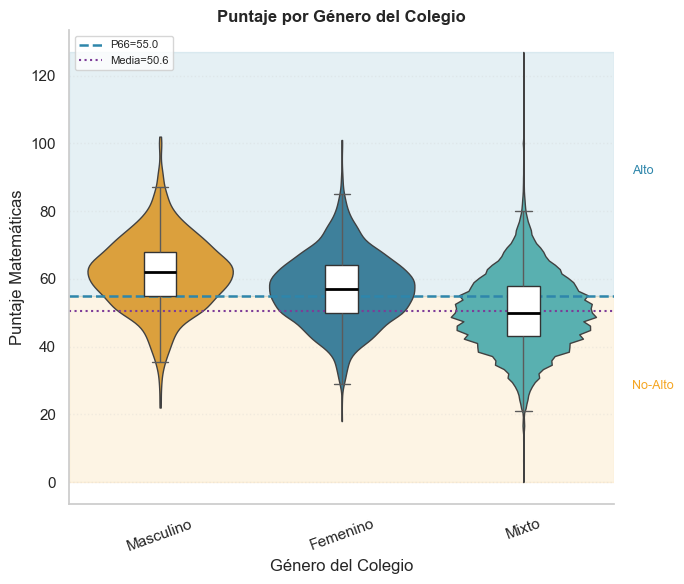

C:\Users\danis\AppData\Local\Temp\ipykernel_24700\804105823.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


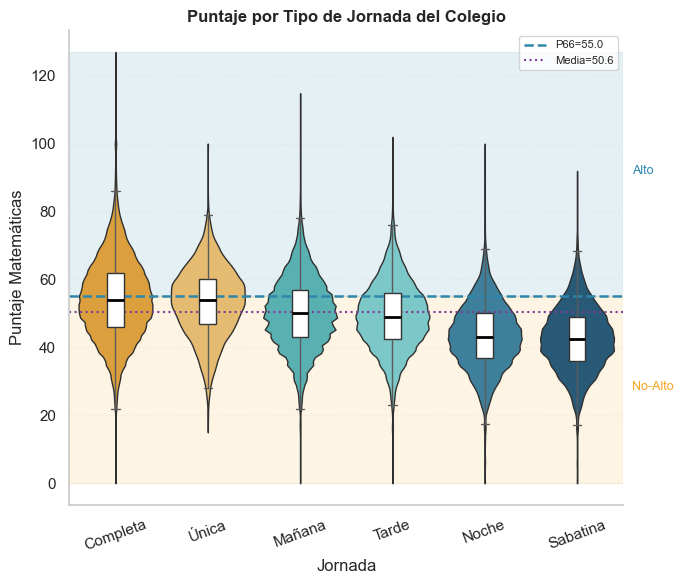

In [33]:
#df limpio
df_plot = df_limpio.copy()

#colores bonitos binarios
C = {
    'No-Alto': '#F5A623',
    'Alto': '#2E86AB'
}

#titulos bonitos
TITULOS = {
    'AREA': 'Puntaje por Área de Ubicación del Colegio',
    'BILINGUE': 'Puntaje por Colegio Bilingüe',
    'GENERO': 'Puntaje por Género del Colegio',
    'JORNADA': 'Puntaje por Tipo de Jornada del Colegio'
}

#umbral
p66   = df_plot['PUNT_MATEMATICAS'].quantile(0.66)
media = df_plot['PUNT_MATEMATICAS'].mean()
ymin  = df_plot['PUNT_MATEMATICAS'].min()
ymax  = df_plot['PUNT_MATEMATICAS'].max()

#variables
cats = [
    ('AREA', 'Área de Ubicación'),
    ('BILINGUE', 'Bilingüe'),
    ('GENERO', 'Género del Colegio'),
    ('JORNADA', 'Jornada'),
]

for var, label in cats:

    #nueva figura por caract
    fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')
    ax.set_facecolor('white')

    #categorias
    if var == 'AREA':
        df_plot['CAT'] = np.where(
            df_plot['COLE_AREA_UBICACION_NUM'] == 0, 'Urbano', 'Rural'
        )
        palette = ['#4ABFBF', '#2E86AB']

    elif var == 'BILINGUE':
        df_plot['CAT'] = np.where(
            df_plot['COLE_BILINGUE_NUM'] == 1, 'Sí', 'No'
        )
        palette = ['#4ABFBF', '#F5A623']

    elif var == 'GENERO':
        df_plot['CAT'] = np.select(
            [
                df_plot.get('COLE_GENERO_FEMENINO',0)==1,
                df_plot.get('COLE_GENERO_MASCULINO',0)==1,
                df_plot.get('COLE_GENERO_MIXTO',0)==1
            ],
            ['Femenino', 'Masculino', 'Mixto'],
            default='Otro'
        )
        palette = ['#F5A623', '#2E86AB', '#4ABFBF']

    elif var == 'JORNADA':
        df_plot['CAT'] = np.select(
            [
                df_plot.get('COLE_JORNADA_COMPLETA',0)==1,
                df_plot.get('COLE_JORNADA_MAÑANA',0)==1,
                df_plot.get('COLE_JORNADA_TARDE',0)==1,
                df_plot.get('COLE_JORNADA_NOCHE',0)==1,
                df_plot.get('COLE_JORNADA_SABATINA',0)==1,
                df_plot.get('COLE_JORNADA_UNICA',0)==1
            ],
            ['Completa', 'Mañana', 'Tarde', 'Noche', 'Sabatina', 'Única'],
            default='Otro'
        )
        palette = ['#F5A623', '#F8C15C', '#4ABFBF',
                   '#6FD4D4', '#2E86AB', '#1B5E84']

    #ordenes
    orden_cat = (
        df_plot.groupby('CAT')['PUNT_MATEMATICAS']
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    #diagrama de violin
    sns.violinplot(
        data=df_plot,
        x='CAT',
        y='PUNT_MATEMATICAS',
        order=orden_cat,
        palette=palette,
        inner=None,
        linewidth=1,
        cut=0,
        ax=ax
    )

    #caja y bigotes
    sns.boxplot(
        data=df_plot,
        x='CAT',
        y='PUNT_MATEMATICAS',
        order=orden_cat,
        width=0.18,
        showcaps=True,
        boxprops={'facecolor': 'white', 'edgecolor': '#333333'},
        medianprops={'color': 'black', 'linewidth': 2},
        showfliers=False,
        ax=ax,
        zorder=3
    )

    #sombra atras
    ax.axhspan(ymin, p66, alpha=0.12, color=C['No-Alto'], zorder=0)
    ax.axhspan(p66, ymax, alpha=0.12, color=C['Alto'], zorder=0)

    #divisiones
    ax.axhline(p66,   color=C['Alto'], ls='--', lw=1.8, label=f'P66={p66:.1f}')
    ax.axhline(media, color='#7D3C98', ls=':',  lw=1.5, label=f'Media={media:.1f}')

    #etiquetas de la zona
    ax.text(len(orden_cat)-0.4, (ymin+p66)/2, 'No-Alto',
            color=C['No-Alto'], fontsize=9)

    ax.text(len(orden_cat)-0.4, (p66+ymax)/2, 'Alto',
            color=C['Alto'], fontsize=9)

   #bonito
    ax.set_title(TITULOS[var], fontweight='bold', fontsize=12)
    ax.set_xlabel(label)
    ax.set_ylabel('Puntaje Matemáticas')

    ax.tick_params(axis='x', rotation=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.25)

    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## tablas de conteo y porcentajes

In [34]:
#contar cuantas de cada nivel vs cada categoria de colegio (BINARIO)

def resumen_categoria(df, variable):

    #variables

    if variable == 'COLE_AREA_UBICACION':
        df['CAT'] = np.where(
            df['COLE_AREA_UBICACION_NUM'] == 0, 'Urbano', 'Rural'
        )

    elif variable == 'COLE_BILINGUE':
        df['CAT'] = np.where(
            df['COLE_BILINGUE_NUM'] == 1, 'Sí', 'No'
        )

    elif variable == 'COLE_GENERO':
        df['CAT'] = np.select(
            [
                df.get('COLE_GENERO_FEMENINO',0)==1,
                df.get('COLE_GENERO_MASCULINO',0)==1,
                df.get('COLE_GENERO_MIXTO',0)==1
            ],
            ['Femenino', 'Masculino', 'Mixto'],
            default='Otro'
        )

    elif variable == 'COLE_JORNADA':
        df['CAT'] = np.select(
            [
                df.get('COLE_JORNADA_COMPLETA',0)==1,
                df.get('COLE_JORNADA_MAÑANA',0)==1,
                df.get('COLE_JORNADA_TARDE',0)==1,
                df.get('COLE_JORNADA_NOCHE',0)==1,
                df.get('COLE_JORNADA_SABATINA',0)==1,
                df.get('COLE_JORNADA_UNICA',0)==1
            ],
            ['Completa', 'Mañana', 'Tarde', 'Noche', 'Sabatina', 'Única'],
            default='Otro'
        )

    #binarias
    target = 'ALTO_RENDIMIENTO'

    # conteo
    tabla = pd.crosstab(df['CAT'], df[target])

    # porcentaje
    tabla_pct = pd.crosstab(
        df['CAT'],
        df[target],
        normalize='index'
    ) * 100

    tabla_pct.columns = ['No-Alto', 'Alto']
    tabla.columns = ['No-Alto', 'Alto']

    # ── output ─────────────
    print(f"\nConteo — {variable}")
    display(tabla)

    print(f"\nPorcentaje (%) — {variable}")
    display(tabla_pct.round(2))

In [35]:
df_modelo = df_limpio.copy()

# crear target binario si no existe
p66 = df_modelo['PUNT_MATEMATICAS'].quantile(0.66)
df_modelo['ALTO_RENDIMIENTO'] = (df_modelo['PUNT_MATEMATICAS'] >= p66).astype(int)

# ejecutar
resumen_categoria(df_modelo, 'COLE_AREA_UBICACION')
resumen_categoria(df_modelo, 'COLE_BILINGUE')
resumen_categoria(df_modelo, 'COLE_GENERO')
resumen_categoria(df_modelo, 'COLE_JORNADA')


Conteo — COLE_AREA_UBICACION


,No-Alto,Alto
CAT,,
Rural,41467,30846
Urbano,211197,109755



Porcentaje (%) — COLE_AREA_UBICACION


,No-Alto,Alto
CAT,,
Rural,57.34,42.66
Urbano,65.80,34.20



Conteo — COLE_BILINGUE


...

,No-Alto,Alto
CAT,,
Femenino,40.19,59.81
Masculino,24.15,75.85
Mixto,64.68,35.32



Conteo — COLE_JORNADA


,No-Alto,Alto
CAT,,
Completa,51067,48439
Mañana,117203,60578
Noche,22462,3107
Sabatina,21781,2501
Tarde,21435,9252
Única,18716,16724



Porcentaje (%) — COLE_JORNADA


,No-Alto,Alto
CAT,,
Completa,51.32,48.68
Mañana,65.93,34.07
Noche,87.85,12.15
Sabatina,89.70,10.30
Tarde,69.85,30.15
Única,52.81,47.19


## Mapas de Calor

In [36]:
# ── construir pivot DESDE df_limpio ─────────────────────────

df_plot = df_limpio.copy()

# ── crear perfil (Área + Bilingüe) ─────────────────────────
df_plot['PERFIL'] = (
    df_plot['COLE_AREA_UBICACION_NUM'].map({0: 'Urbano', 1: 'Rural'}) + ' / ' +
    df_plot['COLE_BILINGUE_NUM'].map({1: 'Bilingüe', 0: 'No bilingüe'})
)

# ── crear jornada label ─────────────────────────
def get_jornada(row):
    if row.get('COLE_JORNADA_COMPLETA', 0) == 1:
        return 'Completa'
    elif row.get('COLE_JORNADA_UNICA', 0) == 1:
        return 'Única'
    elif row.get('COLE_JORNADA_MAÑANA', 0) == 1:
        return 'Mañana'
    elif row.get('COLE_JORNADA_TARDE', 0) == 1:
        return 'Tarde'
    elif row.get('COLE_JORNADA_NOCHE', 0) == 1:
        return 'Noche'
    elif row.get('COLE_JORNADA_SABATINA', 0) == 1:
        return 'Sabatina'
    else:
        return 'Otra'

df_plot['JORNADA_LABEL'] = df_plot.apply(get_jornada, axis=1)

# ── crear pivot ─────────────────────────
pivot = df_plot.pivot_table(
    values='PUNT_MATEMATICAS',
    index='JORNADA_LABEL',
    columns='PERFIL',
    aggfunc='mean'
).round(1)

# ordenar filas (mejor visual)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

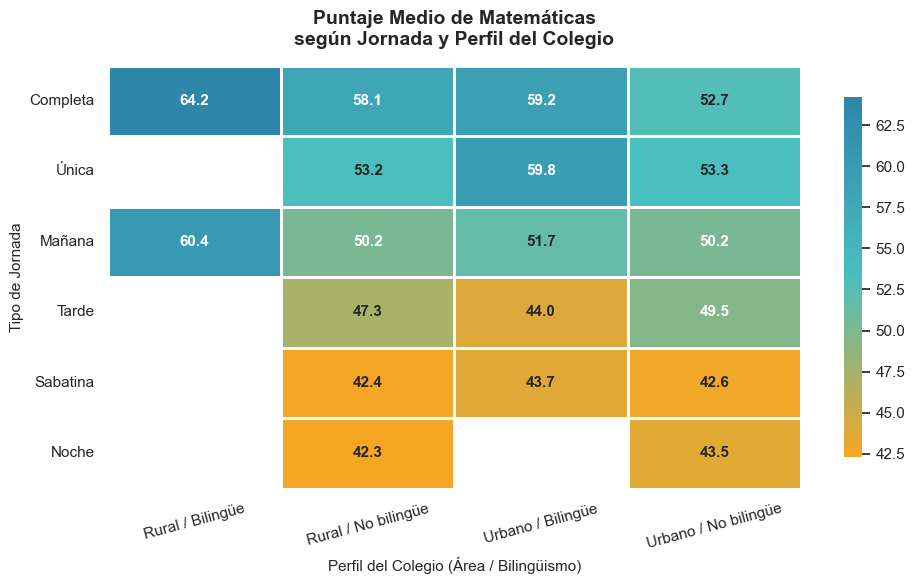

In [37]:
from matplotlib.colors import LinearSegmentedColormap

cmap_custom = LinearSegmentedColormap.from_list(
    'custom_palette',
    ['#F5A623', '#4ABFBF', '#2E86AB']
)

sns.set_theme(style='white')

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap=cmap_custom,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'},
    cbar_kws={'shrink': 0.85},
    ax=ax
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    'Puntaje Medio de Matemáticas\nsegún Jornada y Perfil del Colegio',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Perfil del Colegio (Área / Bilingüismo)', fontsize=11)
ax.set_ylabel('Tipo de Jornada', fontsize=11)

ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

ax.grid(False)

plt.tight_layout()
plt.show()

# Dataframe final para hacer el modelo

In [39]:
#df limpio y finalmente df modelo
df_modelo = df_limpio.copy()

#esto era antes
if 'NIVEL_MATEMATICAS' in df_modelo.columns:
    df_modelo = df_modelo.drop(columns=['NIVEL_MATEMATICAS'])

#objetivo: binario alto o no alto
p66 = df_modelo['PUNT_MATEMATICAS'].quantile(0.66)

df_modelo['ALTO_RENDIMIENTO'] = (
    df_modelo['PUNT_MATEMATICAS'] >= p66
).astype(int)

#columnas finales
CARACTERISTICAS = [
    col for col in df_modelo.columns
    if col not in ['PUNT_MATEMATICAS', 'ALTO_RENDIMIENTO']
]

TARGET = 'ALTO_RENDIMIENTO'

#limpieza final
df_modelo = df_modelo.apply(pd.to_numeric, errors='coerce')
df_modelo = df_modelo.dropna().reset_index(drop=True)

df_modelo[CARACTERISTICAS] = df_modelo[CARACTERISTICAS].astype(int)

#verificar
print("Distribución:")
print(df_modelo[TARGET].value_counts().rename({0: 'No-Alto', 1: 'Alto'}))

df_modelo.head()


Distribución:
ALTO_RENDIMIENTO
No-Alto    252664
Alto       140601
Name: count, dtype: int64


,COLE_AREA_UBICACION_NUM,COLE_BILINGUE_NUM,COLE_GENERO_FEMENINO,COLE_GENERO_MASCULINO,COLE_GENERO_MIXTO,COLE_JORNADA_COMPLETA,COLE_JORNADA_MAÑANA,COLE_JORNADA_NOCHE,COLE_JORNADA_SABATINA,COLE_JORNADA_TARDE,COLE_JORNADA_UNICA,PUNT_MATEMATICAS,ALTO_RENDIMIENTO
0,0,0,0,0,1,0,0,0,0,0,1,26.0,0
1,0,0,0,0,1,0,0,0,1,0,0,60.0,1
2,0,0,0,0,1,1,0,0,0,0,0,54.0,0
3,1,0,0,0,1,0,0,0,1,0,0,45.0,0
4,0,0,0,0,1,0,0,0,0,0,1,64.0,1


In [40]:
#final final
ruta = "df_modelo_preg1.csv"

df_modelo.to_csv(ruta, index=False)
df_modelo.head()

,COLE_AREA_UBICACION_NUM,COLE_BILINGUE_NUM,COLE_GENERO_FEMENINO,COLE_GENERO_MASCULINO,COLE_GENERO_MIXTO,COLE_JORNADA_COMPLETA,COLE_JORNADA_MAÑANA,COLE_JORNADA_NOCHE,COLE_JORNADA_SABATINA,COLE_JORNADA_TARDE,COLE_JORNADA_UNICA,PUNT_MATEMATICAS,ALTO_RENDIMIENTO
0,0,0,0,0,1,0,0,0,0,0,1,26.0,0
1,0,0,0,0,1,0,0,0,1,0,0,60.0,1
2,0,0,0,0,1,1,0,0,0,0,0,54.0,0
3,1,0,0,0,1,0,0,0,1,0,0,45.0,0
4,0,0,0,0,1,0,0,0,0,0,1,64.0,1
